# NPCI Upskilling - Data Science and Engineering Track

## A program by IIITH and TalentSprint

### Playground Challenge 4: BitCoin_Forecasting_ARMA [20 points]


## <b><font color="red">Please run this solution notebook on your Google Colab T4 GPU runtime</font></b>

To select the T4 GPU, follow these steps:

Runtime >> Change runtime type >> T4 GPU >> save

## Learning Objectives

At the end of the experiment, you will be able to :

* perform EDA on time series data
* analyze the auto correlation and partial auto correlation plots
* implement the ARMA model and forecast the bit coin price

## Dataset



Bitcoin is a digital currency created in January 2009. It follows the ideas set out in a whitepaper by the mysterious and pseudonymous Satoshi Nakamoto. The identity of the person or persons who created the technology is still a mystery. Bitcoin offers the promise of lower transaction fees than traditional online payment mechanisms and, unlike government-issued currencies, it is operated by a decentralized authority.

Data Description
This dataset provides the history of daily prices of Bitcoin. The data starts from 17-Sep-2014 and is updated till 09-July-2021. All the column descriptions are provided below.

* Date: Day/Month/Year
* Open: Price from the first transaction of a trading day
* High: Maximum price in a trading day
* Low: Minimum price in a trading day
* Close: Price from the last transaction of a trading day
* Adj Close: Closing price adjusted to reflect the value after accounting for any corporate actions
* Volume: Number of units traded in a day

## Problem Statement

Perform EDA and forecast the Bitcoin price using ARMA model on timeseries (bitcoin) data.

## Grading = 20 Points

In [356]:
# @title Download Dataset
# !wget -qq !wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/BTC.csv
# print("Dataset downloaded successfully!!")


from utility import download_and_unzip

download_and_unzip(
    filename="BTC.csv",
    url="https://cdn.iisc.talentsprint.com/CDS/MiniProjects/BTC.csv",
)

print("Data downloaded successfully")


Data downloaded successfully


### Import required Packages

In [357]:
from matplotlib import pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import month_plot, seasonal_plot, quarter_plot

import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import itertools

warnings.simplefilter("ignore")


### Load the data and perform EDA [4 points]

Hint: Refer to this ['Bitcoin dataset EDA'](https://cdn.iisc.talentsprint.com/CDS/Assignments/Module6/M6_SNB_MiniProject_3_BitCoin_Forecasting_ARMA_Exploratory%20Data%20Analysis.pdf)

In [358]:
# YOUR CODE HERE
df = pd.read_csv("BTC.csv", index_col="Date", parse_dates=True)
df.sort_index(inplace=True)
df


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,2.105680e+07
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,3.448320e+07
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,3.791970e+07
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,3.686360e+07
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,2.658010e+07
...,...,...,...,...,...,...
2021-08-06,40865.867188,43271.660156,39932.179688,42816.500000,42816.500000,3.822648e+10
2021-08-07,42832.796875,44689.859375,42618.566406,44555.800781,44555.800781,4.003086e+10
2021-08-08,44574.437500,45282.351563,43331.910156,43798.117188,43798.117188,3.630266e+10


In [359]:
# Display basic information
print("Original DataFrame Info:")
df.info()
print("\nOriginal DataFrame Head:")
print(df.head())
print("\nOriginal DataFrame Description:")
print(df.describe())
print("\nMissing values before processing:")
print(df.isnull().sum())


Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2520 entries, 2014-09-17 to 2021-08-10
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2516 non-null   float64
 1   High       2516 non-null   float64
 2   Low        2516 non-null   float64
 3   Close      2516 non-null   float64
 4   Adj Close  2516 non-null   float64
 5   Volume     2516 non-null   float64
dtypes: float64(6)
memory usage: 137.8 KB

Original DataFrame Head:
                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2014-09-17  465.864014  468.174011  452.421997  457.334015  457.334015   
2014-09-18  456.859985  456.859985  413.104004  424.440002  424.440002   
2014-09-19  424.102997  427.834991  384.532013  394.795990  394.795990   
2014-09-20  394.673004  423.295990  389.882996  408.903992  408.903992   
2014-09-21  408.084

In [360]:
# For time series analysis, let's focus on the 'Close' price
df["Close"].fillna(method="ffill", inplace=True)
df["Close"].fillna(method="bfill", inplace=True)

# Check for any remaining NaN, inf, -inf values in 'Close' and replace with 0 if found (as per note)
if df["Close"].isnull().any():
    print(
        "Warning: NaN values still present in 'Close' after fillna. Replacing with 0."
    )
    df["Close"].fillna(0, inplace=True)
if np.isinf(df["Close"]).any() or np.isneginf(df["Close"]).any():
    print("Warning: Inf values present in 'Close'. Replacing with 0.")
    df["Close"].replace([np.inf, -np.inf], 0, inplace=True)

print("\nMissing values after processing:")
print(df.isnull().sum())



Missing values after processing:
Open         4
High         4
Low          4
Close        0
Adj Close    4
Volume       4
dtype: int64


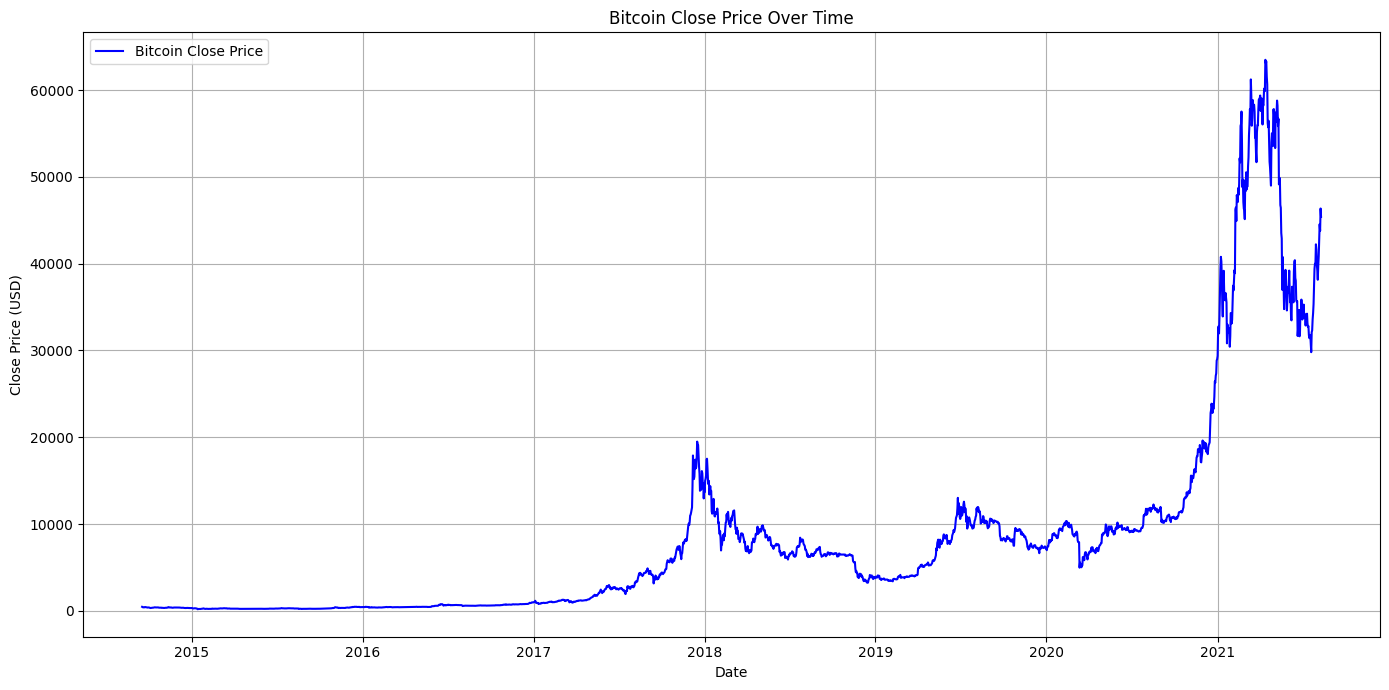

In [361]:
# Plot the 'Close' price over time
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["Close"], label="Bitcoin Close Price", color="blue")
plt.title("Bitcoin Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [362]:
df["Year"] = df.index.year
df["Quarter"] = df.index.quarter
df["Month"] = df.index.month


In [363]:
# Group by Year and Month, and count the number of transactions (rows)
transactions_table = df.groupby(["Year", "Month"]).size().unstack(fill_value=0)

print("Number of transactions per Year and Month:\n")
print(transactions_table)


Number of transactions per Year and Month:

Month  1   2   3   4   5   6   7   8   9   10  11  12
Year                                                 
2014    0   0   0   0   0   0   0   0  14  31  30  31
2015   31  28  31  30  31  30  31  31  30  31  30  31
2016   31  29  31  30  31  30  31  31  30  31  30  31
2017   31  28  31  30  31  30  31  31  30  31  30  31
2018   31  28  31  30  31  30  31  31  30  31  30  31
2019   31  28  31  30  31  30  31  31  30  31  30  31
2020   31  29  31  30  31  30  31  31  30  31  30  31
2021   31  28  31  30  31  30  31  10   0   0   0   0


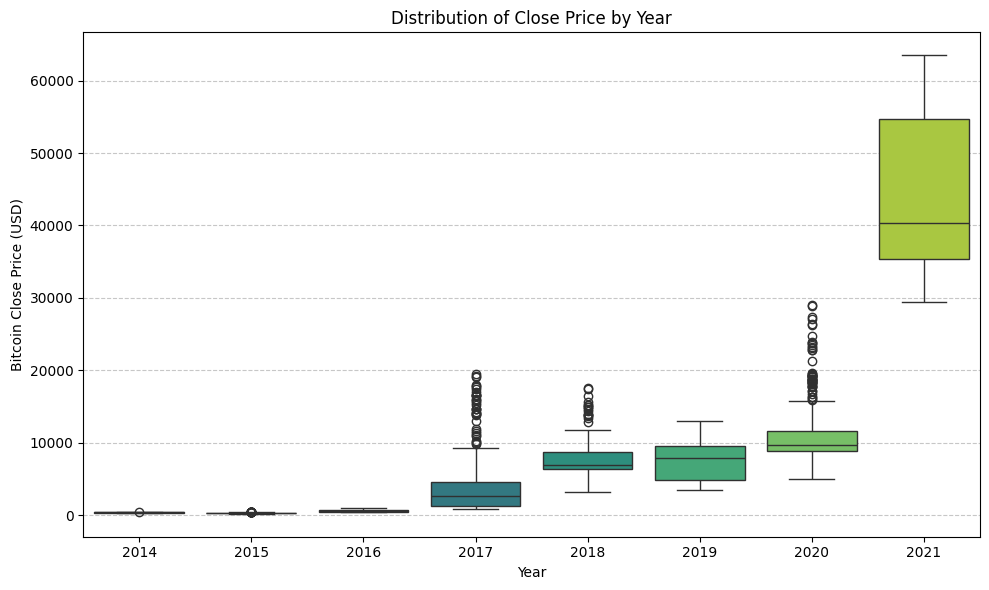

In [364]:
# Box plot to see distribution of close price in each year

plt.figure(figsize=(10, 6))
sns.boxplot(x="Year", y="Close", data=df, palette="viridis")
plt.title("Distribution of Close Price by Year")
plt.xlabel("Year")
plt.ylabel("Bitcoin Close Price (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


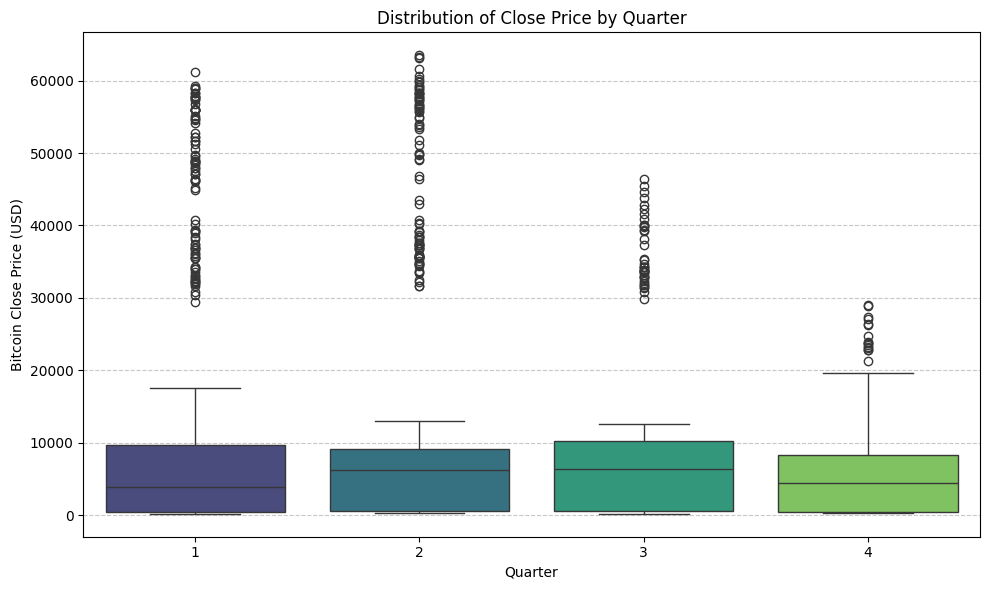

In [365]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Quarter", y="Close", data=df, palette="viridis")
plt.title("Distribution of Close Price by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Bitcoin Close Price (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


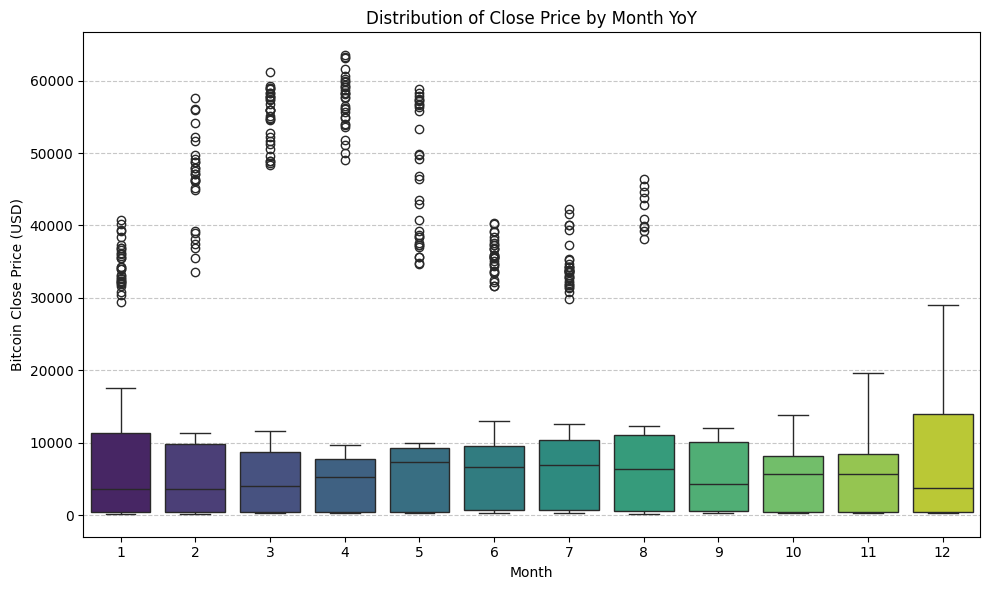

In [366]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Month", y="Close", data=df, palette="viridis")
plt.title("Distribution of Close Price by Month YoY")
plt.xlabel("Month")
plt.ylabel("Bitcoin Close Price (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [367]:
yearly_close = df.groupby("Year")["Close"].sum()
print("\nYearly Close Price:")
print(yearly_close)
percentage_growth = yearly_close.pct_change() * 100
print("\nPercentage Growth Each Year:")
print(percentage_growth)



Yearly Close Price:
Year
2014    3.855147e+04
2015    9.944548e+04
2016    2.080682e+05
2017    1.462202e+06
2018    2.763889e+06
2019    2.699265e+06
2020    4.068348e+06
2021    9.797320e+06
Name: Close, dtype: float64

Percentage Growth Each Year:
Year
2014           NaN
2015    157.955123
2016    109.228426
2017    602.751371
2018     89.022351
2019     -2.338163
2020     50.720590
2021    140.818142
Name: Close, dtype: float64


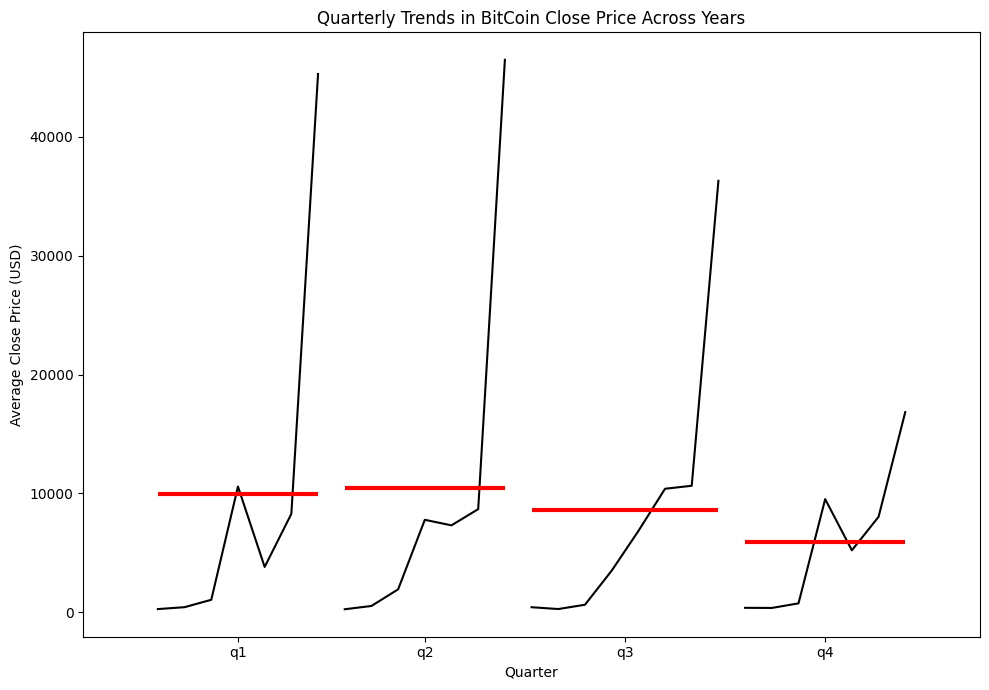

In [368]:
# Resample the daily data to quarterly frequency, taking the mean (or sum) for each quarter
quarterly_close = df["Close"].resample("Q").mean()

fig = plt.figure(figsize=(10, 7))
quarter_plot(quarterly_close, ax=fig.gca())

# # Example: Highlight the year 2020
# highlight_year = 2020
# for i, label in enumerate(fig.gca().get_xticklabels()):
#     print(f"Label {i}: {label.get_text()}")
#     if str(highlight_year) in label.get_text():
#         label.set_color("red")
#         label.set_fontweight("bold")

plt.title("Quarterly Trends in BitCoin Close Price Across Years")
plt.xlabel("Quarter")
plt.ylabel("Average Close Price (USD)")
plt.tight_layout()
plt.show()


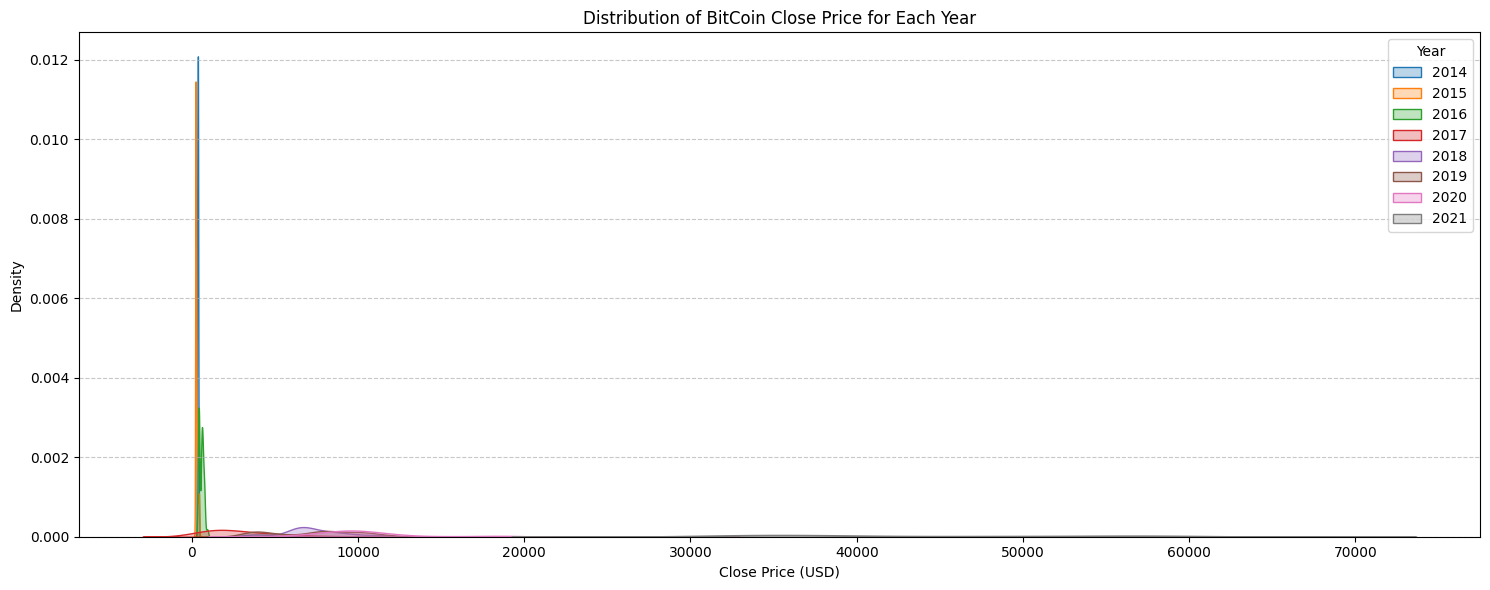

In [369]:
years = df["Year"].unique()
plt.figure(figsize=(15, 6))
for year in years:
    sns.kdeplot(
        df[df["Year"] == year]["Close"],
        label=str(year),
        fill=True,
        alpha=0.3,
    )
plt.title("Distribution of BitCoin Close Price for Each Year")
plt.xlabel("Close Price (USD)")
plt.ylabel("Density")
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#### Analyze the correlation (heatmap) of all the features

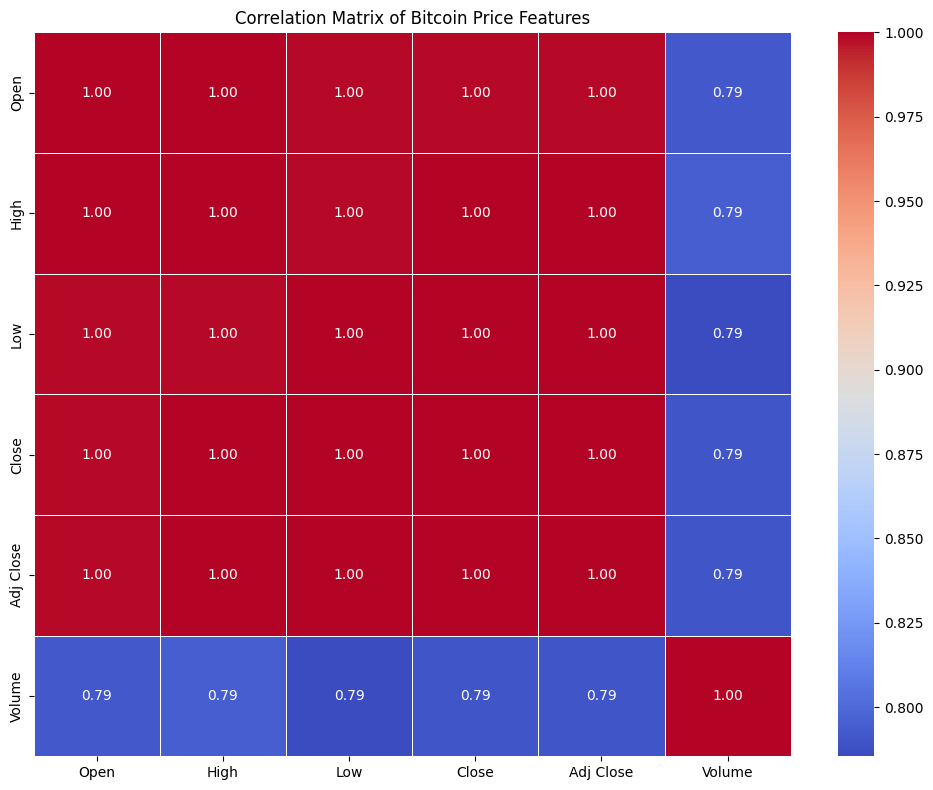

In [370]:
# YOUR CODE HERE
numerical_df = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]]

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Bitcoin Price Features")
plt.tight_layout()
plt.show()


### Test the Stationarity using Augmented Dicky Fuller Test [2 point]

The Augmented Dicky Fuller test is a type of statistical test called a unit root test.

Hint: [tsa.stattools.adfuller](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html)

In [371]:
# YOUR CODE HERE
# The Augmented Dicky Fuller test is a type of statistical test called a unit root test.
# Null Hypothesis (H0): The time series is non-stationary (has a unit root).
# Alternative Hypothesis (H1): The time series is stationary (does not have a unit root).


def adf_test(series):
    result = adfuller(series, autolag="AIC")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value}")
    if result[1] <= 0.05:
        print("Result: Reject H0. The time series is stationary.")
    else:
        print("Result: Fail to reject H0. The time series is non-stationary.")


print("\n--- ADF Test on Original Close Price ---")
adf_test(df["Close"])



--- ADF Test on Original Close Price ---
ADF Statistic: -0.04014025985682117
p-value: 0.9550839258678315
Critical Values:
	1%: -3.4329757705711432
	5%: -2.862700050059295
	10%: -2.567387539813443
Result: Fail to reject H0. The time series is non-stationary.


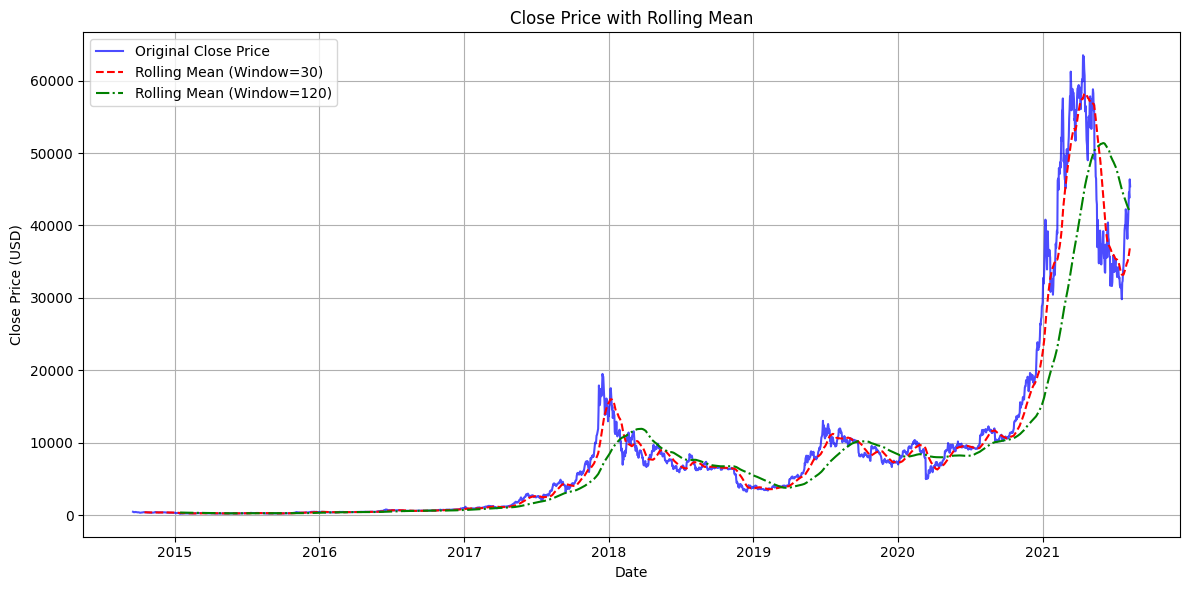

In [372]:
plt.figure(figsize=(12, 6))
plt.plot(
    df.index,
    df["Close"],
    label="Original Close Price",
    color="blue",
    alpha=0.7,
)
plt.plot(
    df.index,
    df["Close"].rolling(window=30).mean(),
    label="Rolling Mean (Window=30)",
    color="red",
    linestyle="--",
)
plt.plot(
    df.index,
    df["Close"].rolling(window=120).mean(),
    label="Rolling Mean (Window=120)",
    color="green",
    linestyle="-.",
)
plt.title("Close Price with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Identify the trends and seasonality from the given time series data [4 points]

* Apply seasonal decompose and plot the results
* Check the stationarity of data using rolling mean and rolling standard deviation.
* Make the time series data stationary
  * Apply a log transformation to reduce the variance of the series
  * Eliminate the Trend and Seasonality by Differencing

**Note:** Ensure timeseries without NaN, inf, -inf values, Replace with 0 if found.

Read more about stationarity of a timeseries in the following [link](https://machinelearningmastery.com/time-series-data-stationary-python/)

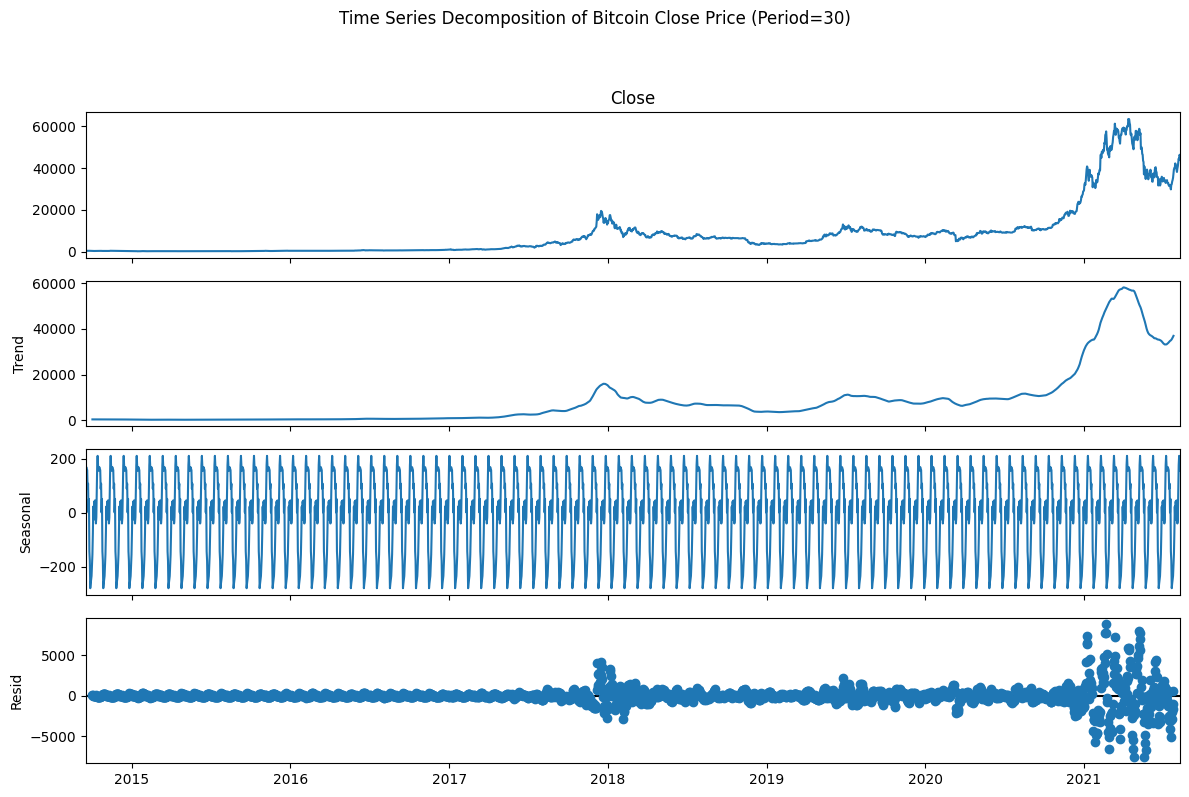

In [373]:
# YOUR CODE HERE
# Ensure the series is not empty and has enough observations for decomposition
if len(df["Close"]) > 30:  # Minimum period for decomposition
    decomposition = seasonal_decompose(
        df["Close"], model="additive", period=30
    )  # Using 30 for a monthly-like period
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle("Time Series Decomposition of Bitcoin Close Price (Period=30)", y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
else:
    print("Not enough data points to perform seasonal decomposition with period=30.")


In [374]:
# Check the stationarity of data using rolling mean and rolling standard deviation.
# Rolling window of 30 days (approx one month)
rolling_mean = df["Close"].rolling(window=30).mean()
rolling_std = df["Close"].rolling(window=30).std()


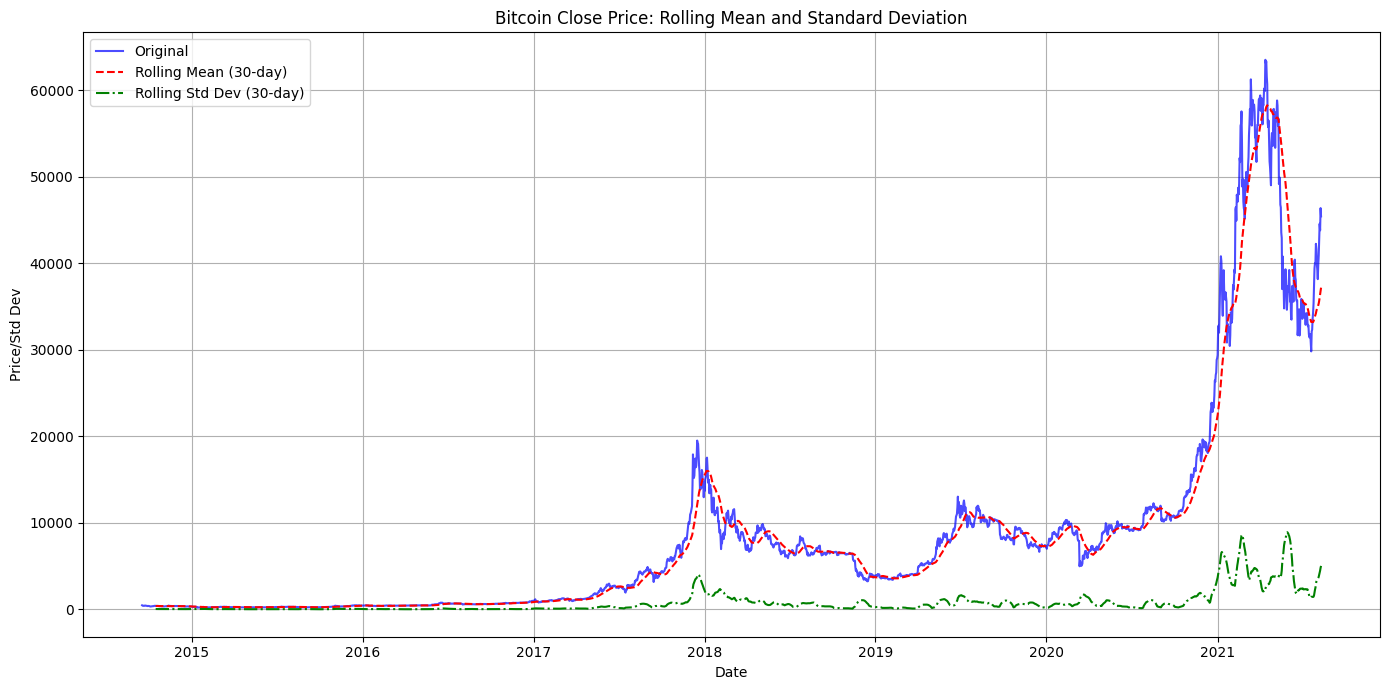

In [375]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["Close"], label="Original", color="blue", alpha=0.7)
plt.plot(
    rolling_mean.index,
    rolling_mean,
    label="Rolling Mean (30-day)",
    color="red",
    linestyle="--",
)
plt.plot(
    rolling_std.index,
    rolling_std,
    label="Rolling Std Dev (30-day)",
    color="green",
    linestyle="-.",
)
plt.title("Bitcoin Close Price: Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Price/Std Dev")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


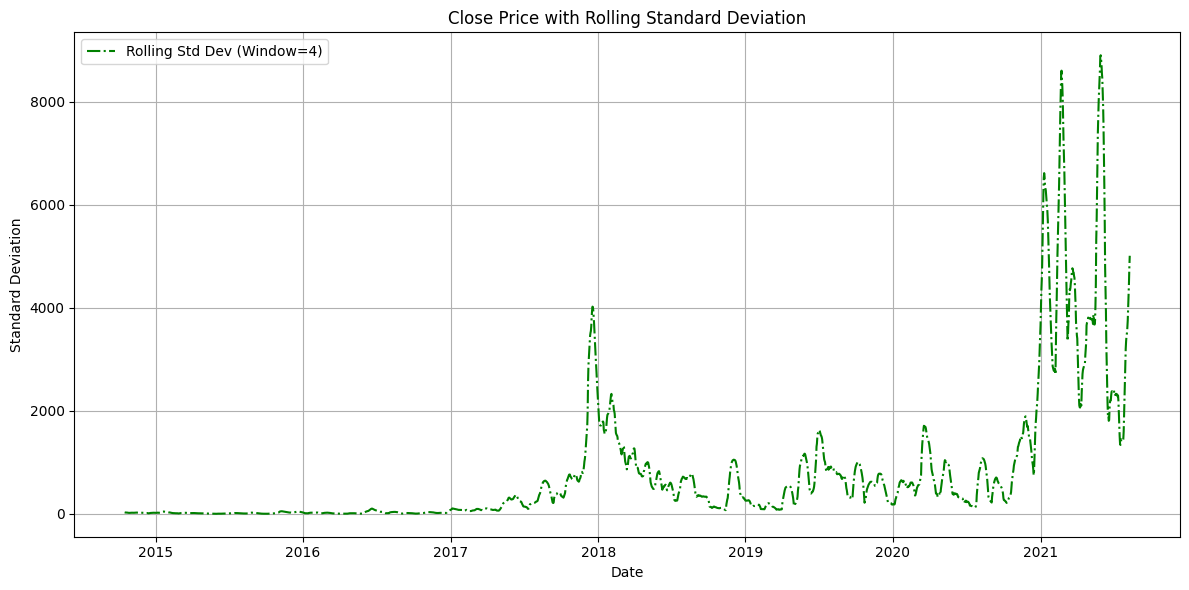

In [376]:
plt.figure(figsize=(12, 6))
plt.plot(
    df.index,
    df["Close"].rolling(window=30).std(),
    label="Rolling Std Dev (Window=4)",
    color="green",
    linestyle="-.",
)
plt.title("Close Price with Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [377]:
# Make the time series data stationary
# Apply a log transformation to reduce the variance of the series
df["log_close"] = np.log(df["Close"])
# Replace any inf or -inf values that might result from log(0) if any were present
df["log_close"].replace([np.inf, -np.inf], np.nan, inplace=True)
df["log_close"].fillna(method="ffill", inplace=True)  # Fill any new NaNs


In [378]:
# Eliminate the Trend and Seasonality by Differencing
# First-order differencing to remove trend
df["diff_log_close"] = df["log_close"].diff().dropna()
df["diff_log_close"].fillna(method="ffill", inplace=True)
df["diff_log_close"].fillna(method="bfill", inplace=True)


In [379]:
# If there's strong seasonality (e.g., yearly for daily data), apply seasonal differencing
# For Bitcoin, strong fixed seasonality is less common, but if it were, you'd do:
# df['seasonal_diff_log_close'] = df['diff_log_close'].diff(periods=365).dropna()
# For this problem, let's stick to first-order differencing as it's common for non-stationary financial data.

print("\nFirst 5 rows of log-transformed and differenced data:")
print(df[["Close", "log_close", "diff_log_close"]].head())



First 5 rows of log-transformed and differenced data:
                 Close  log_close  diff_log_close
Date                                             
2014-09-17  457.334015   6.125414       -0.074643
2014-09-18  424.440002   6.050771       -0.074643
2014-09-19  394.795990   5.978369       -0.072402
2014-09-20  408.903992   6.013480        0.035111
2014-09-21  398.821014   5.988513       -0.024968


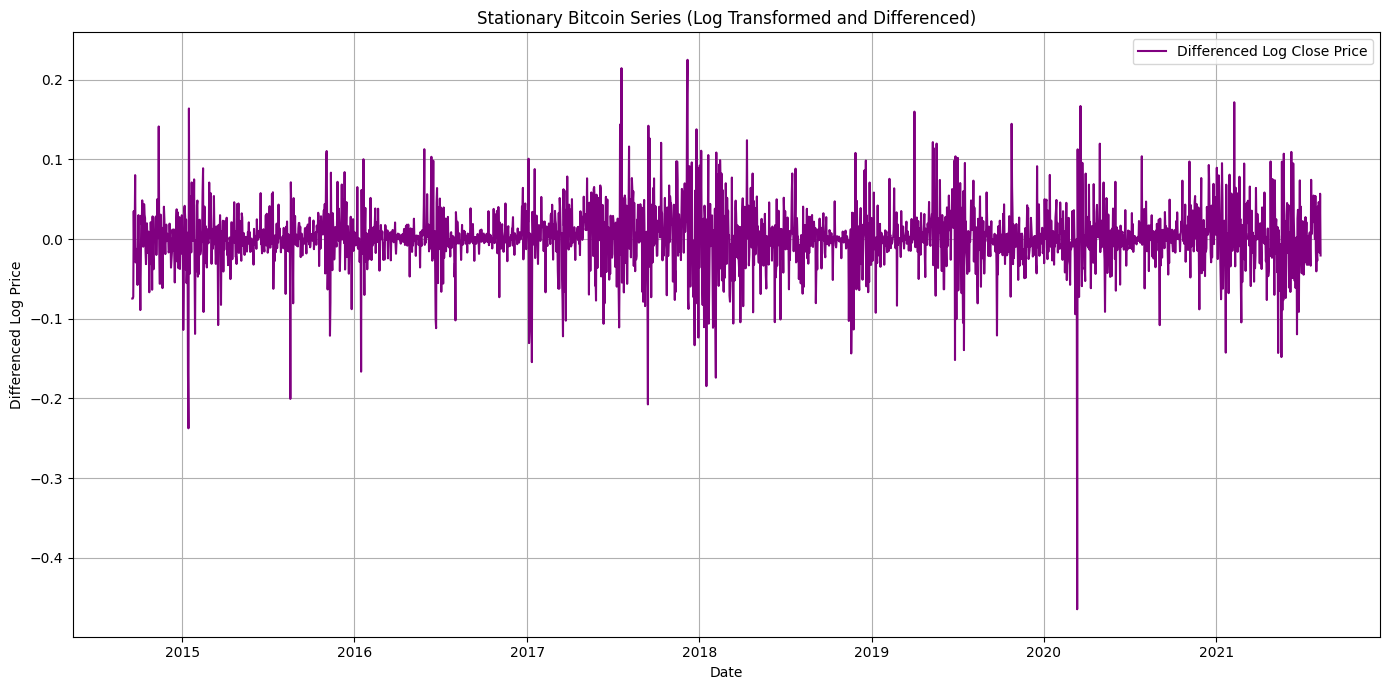

In [380]:
# Plot the differenced series
plt.figure(figsize=(14, 7))
plt.plot(df["diff_log_close"], label="Differenced Log Close Price", color="purple")
plt.title("Stationary Bitcoin Series (Log Transformed and Differenced)")
plt.xlabel("Date")
plt.ylabel("Differenced Log Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Test the Stationarity using Augmented Dicky Fuller Test [2 point]

Verify the stationarity post differencing, using ADF

Hint: [tsa.stattools.adfuller](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html)

In [381]:
# YOUR CODE HERE

# Verify the stationarity post differencing, using ADF
print("\n--- ADF Test on Differenced Log Close Price ---")
adf_test(df["diff_log_close"])



--- ADF Test on Differenced Log Close Price ---
ADF Statistic: -15.082589189533826
p-value: 8.412785128140198e-28
Critical Values:
	1%: -3.4329579682301254
	5%: -2.8626921885291017
	10%: -2.5673833542324727
Result: Reject H0. The time series is stationary.


### Auto Correlation Plot [2 point]

Autocorrelation refers to the degree of correlation between the values of the same variables across different observations in the data.  The concept of autocorrelation is most often discussed in the context of time series data in which observations occur at different points in time.

* Plot the auto correlation function (ACF and PACF)
* Analyse ACF and PACF plots and define AR (p) and MA(q) terms

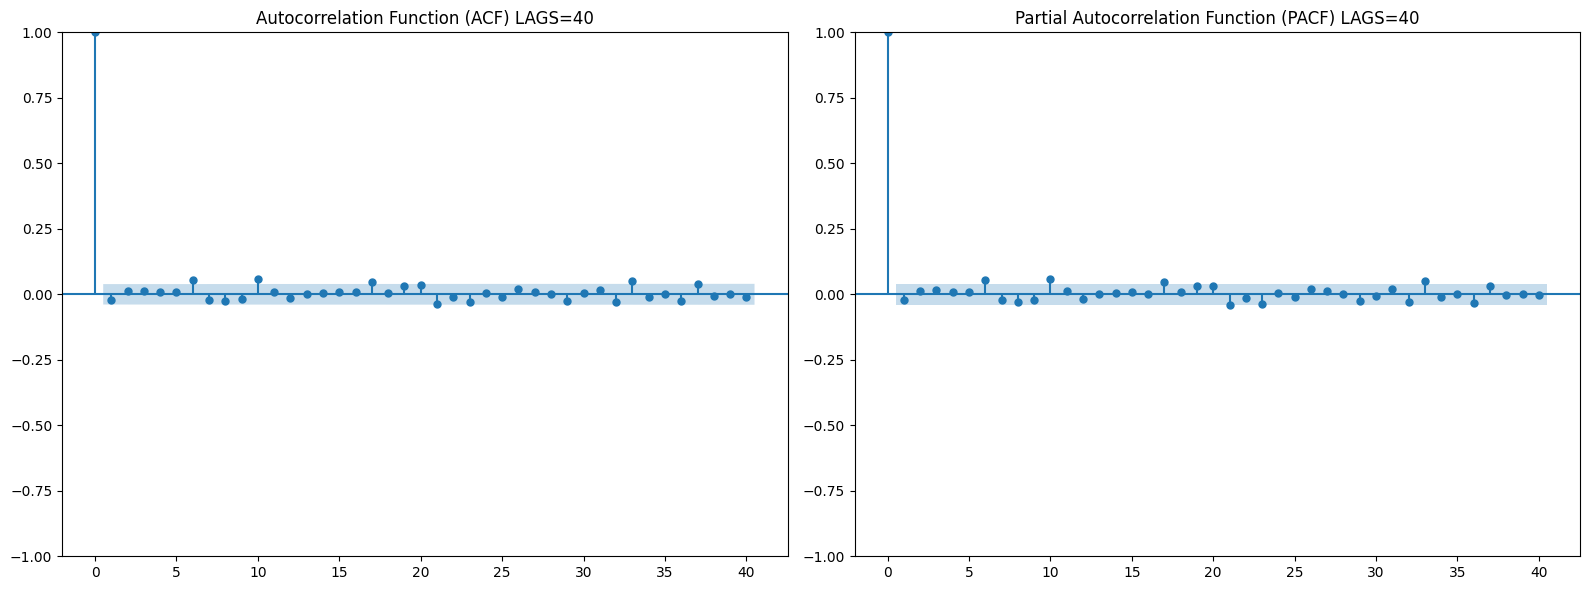

In [382]:
# YOUR CODE HERE

# Plot the auto correlation function (ACF and PACF)
# Use the stationary series (diff_log_close) for ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(
    df["diff_log_close"],
    lags=40,
    ax=axes[0],
    title="Autocorrelation Function (ACF) LAGS=40",
)
plot_pacf(
    df["diff_log_close"],
    lags=40,
    ax=axes[1],
    title="Partial Autocorrelation Function (PACF) LAGS=40",
)

# plot_acf(
#     df["diff_log_close"], lags=50, ax=axes[2], title="Autocorrelation Function (ACF)"
# )
# plot_pacf(
#     df["diff_log_close"],
#     lags=50,
#     ax=axes[3],
#     title="Partial Autocorrelation Function (PACF)",
# )

plt.tight_layout()
plt.show()


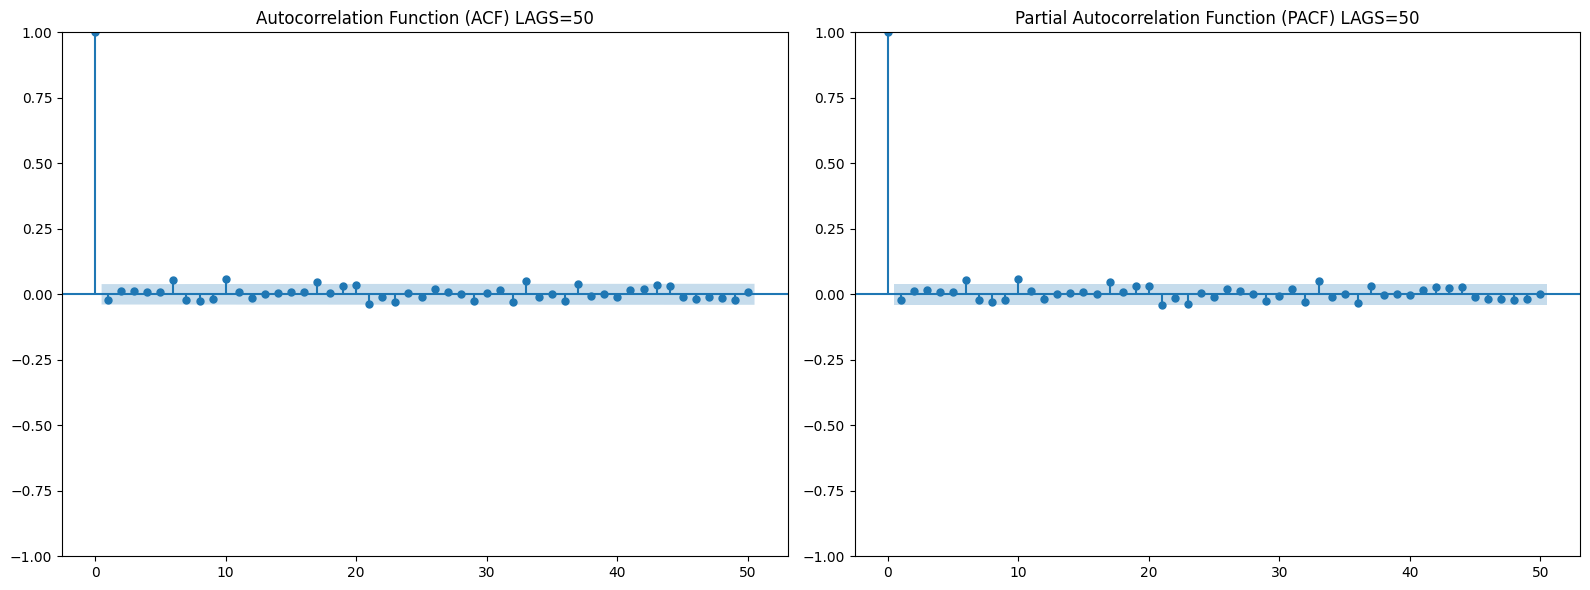

In [383]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(
    df["diff_log_close"],
    lags=50,
    ax=axes[0],
    title="Autocorrelation Function (ACF) LAGS=50",
)
plot_pacf(
    df["diff_log_close"],
    lags=50,
    ax=axes[1],
    title="Partial Autocorrelation Function (PACF) LAGS=50",
)

plt.tight_layout()
plt.show()


In [384]:
# Analyse ACF and PACF plots and define AR (p) and MA(q) terms
# (This analysis will be part of the Report Analysis section)


### Train the Auto Regressive model [2 point]

Hint: sm.tsa.AR()

In [385]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(df["diff_log_close"], lags=[20], return_df=True)
print(lb_test)


      lb_stat  lb_pvalue
20  35.125283   0.019447


In [386]:
# YOUR CODE HERE
# For ARMA, we'll use statsmodels.tsa.arima.model.ARIMA with d=0
# Let's choose p and q based on a preliminary visual inspection of ACF/PACF.
# For example, if PACF cuts off at lag 1 and ACF tails off, AR(1) might be suitable.
# If ACF cuts off at lag 1 and PACF tails off, MA(1) might be suitable.
# For ARMA(p,q), both tail off.
# Let's assume some initial p, q values for demonstration, e.g., p=1, q=1.
# The best p, q will be chosen via AIC in the ARMA section.

# Let's train an AR model (d=0, q=0 for ARIMA)
# Using the log-transformed series for AR model (before differencing if AR is applied to non-stationary data,
# but typically ARMA is on stationary data, so we'll use the differenced series).
# However, the problem explicitly asks for "Auto Regressive model" implying sm.tsa.AR().
# If we were to use sm.tsa.AR(), it's usually applied to stationary data.
# Let's use the `diff_log_close` series.
# For AR model, we look at PACF to determine 'p'. Let's pick p=1 as a common starting point.

# Split data into train and test sets
train_size = int(len(df["diff_log_close"]) * 0.8)
train_data, test_data = (
    df["diff_log_close"][0:train_size],
    df["diff_log_close"][train_size:],
)


In [387]:
# Fit AR model
# model_ar = sm.tsa.AR(train_data).fit(maxlag=1) # maxlag determines p
# print("\nAR Model Summary (p=1):")
# print(model_ar.summary())
# print(f"AR coefficients: {model_ar.params}")

# Note: The problem asks for AR model, but later for ARMA.
# In modern statsmodels, AR is a special case of ARIMA(p,0,0).
# Let's use ARIMA(p,0,0) for AR model for consistency with ARMA.
# Based on PACF, let's try p=1 or p=2. Let's start with p=1.
ar_model = ARIMA(train_data, order=(1, 0, 0))  # ARIMA(p,d,q) where d=0, q=0 for AR
ar_model_fit = ar_model.fit()
print("\nAR(1) Model Summary (on differenced log data):")
print(ar_model_fit.summary())



AR(1) Model Summary (on differenced log data):
                               SARIMAX Results                                
Dep. Variable:         diff_log_close   No. Observations:                 2016
Model:                 ARIMA(1, 0, 0)   Log Likelihood                3630.160
Date:                Sun, 13 Jul 2025   AIC                          -7254.321
Time:                        11:51:10   BIC                          -7237.494
Sample:                    09-17-2014   HQIC                         -7248.145
                         - 03-24-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      1.420      0.156      -0.000       0.003
ar.L1         -0.0135      0.013     -1.025      0.305      -0.039       0.012
sigm

In [389]:
ar_model = ARIMA(train_data, order=(6, 0, 0))
ar_model_fit = ar_model.fit()
print("\nAR(1) Model Summary (on differenced log data):")
print(ar_model_fit.summary())



AR(1) Model Summary (on differenced log data):
                               SARIMAX Results                                
Dep. Variable:         diff_log_close   No. Observations:                 2016
Model:                 ARIMA(6, 0, 0)   Log Likelihood                3633.899
Date:                Sun, 13 Jul 2025   AIC                          -7251.797
Time:                        11:52:00   BIC                          -7206.926
Sample:                    09-17-2014   HQIC                         -7235.328
                         - 03-24-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      1.293      0.196      -0.001       0.003
ar.L1         -0.0162      0.013     -1.205      0.228      -0.043       0.010
ar.L

In [353]:
ar_model = ARIMA(train_data, order=(0, 0, 1))  # ARIMA(p,d,q) where d=0, q=0 for AR
ar_model_fit = ar_model.fit()
print("\nMA(1) Model Summary (on differenced log data):")
print(ar_model_fit.summary())



MA(1) Model Summary (on differenced log data):
                               SARIMAX Results                                
Dep. Variable:         diff_log_close   No. Observations:                 2016
Model:                 ARIMA(0, 0, 1)   Log Likelihood                3630.145
Date:                Sun, 13 Jul 2025   AIC                          -7254.291
Time:                        11:48:28   BIC                          -7237.464
Sample:                    09-17-2014   HQIC                         -7248.115
                         - 03-24-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      1.425      0.154      -0.000       0.003
ma.L1         -0.0172      0.013     -1.298      0.194      -0.043       0.009
sigm

In [ ]:
# TODO treat the outlier as JB probability is 0.
# treat outlier and AR(1) 


In [355]:
ar_model = ARIMA(train_data, order=(1, 0, 1))
ar_model_fit = ar_model.fit()
print("\nARMA(1) Model Summary (on differenced log data):")
print(ar_model_fit.summary())



ARMA(1) Model Summary (on differenced log data):
                               SARIMAX Results                                
Dep. Variable:         diff_log_close   No. Observations:                 2016
Model:                 ARIMA(1, 0, 1)   Log Likelihood                3630.136
Date:                Sun, 13 Jul 2025   AIC                          -7252.273
Time:                        11:48:28   BIC                          -7229.837
Sample:                    09-17-2014   HQIC                         -7244.038
                         - 03-24-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      1.418      0.156      -0.000       0.003
ar.L1          0.1306      1.347      0.097      0.923      -2.509       2.770
ma

### ARMA Model [2 point]

* Train the ARMA model on timeseries data and print AIC value

In [21]:
# YOUR CODE HERE for ARIMA Model
# Train the ARMA model on timeseries data and print AIC value
# We need to select optimal p and q for ARMA(p,q) on the stationary series.
# We can use a grid search to find the best p, q based on AIC.

# Define the p, q parameters to take any value between 0 and 5
p = range(0, 3)  # Example range for p
q = range(0, 3)  # Example range for q
pq = list(itertools.product(p, q))

best_aic = float("inf")
best_order = None
best_arma_model_fit = None

print("\n--- ARMA Model Selection (AIC) ---")
for order in pq:
    try:
        # ARIMA(p, d, q) where d=0 for ARMA
        model_arma = ARIMA(train_data, order=(order[0], 0, order[1]))
        model_arma_fit = model_arma.fit()
        if model_arma_fit.aic < best_aic:
            best_aic = model_arma_fit.aic
            best_order = order
            best_arma_model_fit = model_arma_fit
        print(f"ARMA{order} AIC={model_arma_fit.aic:.2f}")
    except Exception as e:
        # print(f'Could not fit ARMA{order}: {e}')
        continue

print(f"\nBest ARMA Order: {best_order} with AIC: {best_aic:.2f}")



--- ARMA Model Selection (AIC) ---
ARMA(0, 0) AIC=-7255.95
ARMA(0, 1) AIC=-7254.29
ARMA(0, 2) AIC=-7252.32
ARMA(1, 0) AIC=-7254.32
ARMA(1, 1) AIC=-7252.27
ARMA(1, 2) AIC=-7250.65
ARMA(2, 0) AIC=-7252.33
ARMA(2, 1) AIC=-7250.34
ARMA(2, 2) AIC=-7248.58

Best ARMA Order: (0, 0) with AIC: -7255.95


In [22]:
print("\nBest ARMA Model Summary:")
print(best_arma_model_fit.summary())



Best ARMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:         diff_log_close   No. Observations:                 2016
Model:                          ARIMA   Log Likelihood                3629.976
Date:                Sat, 12 Jul 2025   AIC                          -7255.952
Time:                        23:33:53   BIC                          -7244.734
Sample:                    09-17-2014   HQIC                         -7251.834
                         - 03-24-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      1.406      0.160      -0.001       0.003
sigma2         0.0016   1.88e-05     84.980      0.000       0.002       0.002
Ljung-Box (L1) (Q):       

#### Plot the predictions for timeseries data [2 point]

In [23]:
# YOUR CODE HERE
# Forecast using the best ARMA model
# The forecast is for the differenced log series. We need to inverse transform it.
forecast_steps = len(test_data)
# Get predictions on the test set
arma_predictions_diff_log = best_arma_model_fit.predict(
    start=len(train_data), end=len(df["diff_log_close"]) - 1
)


In [24]:
# To get predictions in the original scale, we need to inverse the differencing and log transformation.
# This requires the last value of the training set's log_close and original close.

# Get the last log_close value from the training data
last_log_train = df["log_close"].iloc[train_size - 1]


In [25]:
# Inverse differencing: predicted_log_value[t] = predicted_diff_log_value[t] + actual_log_value[t-1]
# Initialize a list to store inverse transformed log predictions
arma_predictions_log = [last_log_train]
for i in range(len(arma_predictions_diff_log)):
    # The first prediction uses the last actual log value from train_data
    # Subsequent predictions use the previously predicted log value
    if i == 0:
        arma_predictions_log.append(arma_predictions_diff_log.iloc[i] + last_log_train)
    else:
        arma_predictions_log.append(
            arma_predictions_diff_log.iloc[i] + arma_predictions_log[-1]
        )


In [26]:
# Remove the initial last_log_train value which was just for calculation
arma_predictions_log = arma_predictions_log[1:]

# Convert list to pandas Series with test data index
arma_predictions_log_series = pd.Series(arma_predictions_log, index=test_data.index)

# Inverse log transformation: exp(predicted_log_value)
arma_predictions_original_scale = np.exp(arma_predictions_log_series)

# Evaluate RMSE on the original scale
rmse = sqrt(
    mean_squared_error(df["Close"][train_size:], arma_predictions_original_scale)
)
print(f"\nRMSE on original scale: {rmse:.2f}")



RMSE on original scale: 23213.20


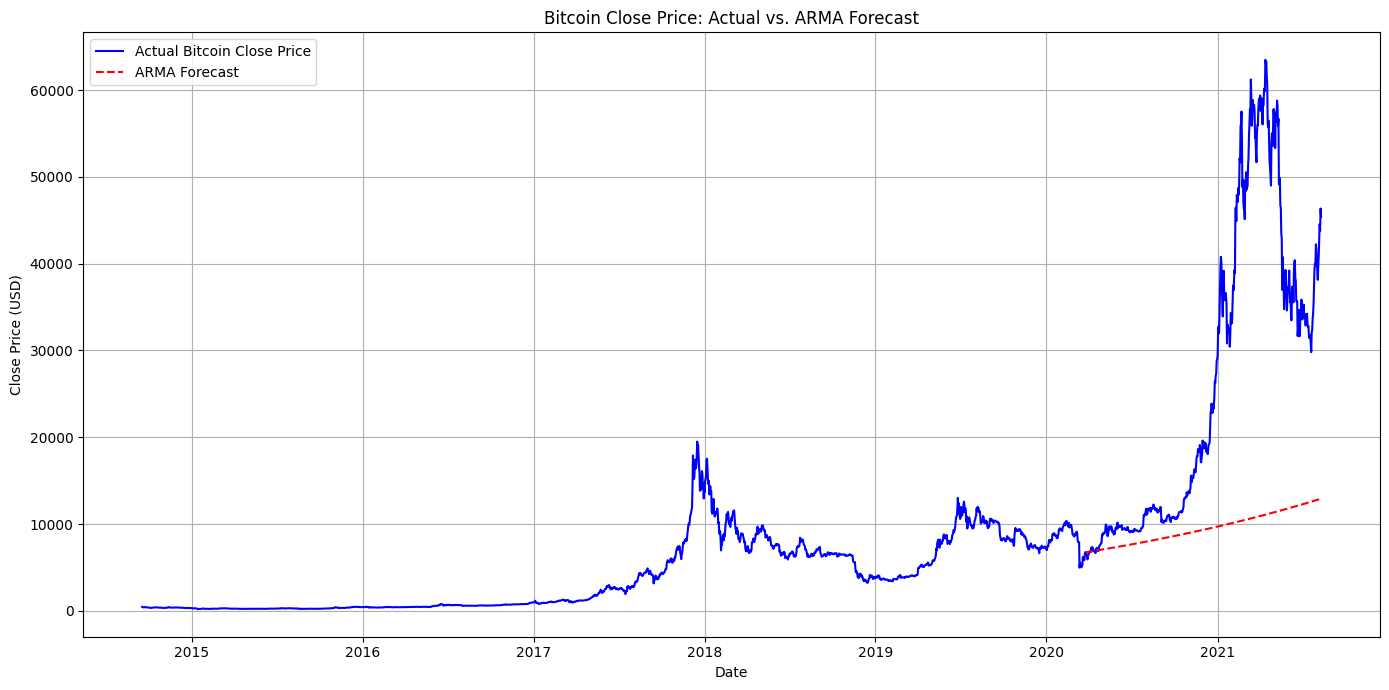

In [27]:
# Plot actual vs. predicted values on the original scale
plt.figure(figsize=(14, 7))
plt.plot(
    df["Close"].index, df["Close"], label="Actual Bitcoin Close Price", color="blue"
)
plt.plot(
    arma_predictions_original_scale.index,
    arma_predictions_original_scale,
    label="ARMA Forecast",
    color="red",
    linestyle="--",
)
plt.title("Bitcoin Close Price: Actual vs. ARMA Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Report Analysis

* Discuss how sudden effects of bitcoin price affects the model parameters
* State your observations about the trend and seasonality of the timeseries data
* Discuss how you selected ARMA (p and q) terms.
* Interpret the AIC value obtained for the ARMA model